In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [6]:
train_dir = 'chest_xray/train'
test_dir  = 'chest_xray/test'
val_dir   = 'chest_xray/val'

# Verify folders
print("Train:", os.listdir(train_dir))
print("Test:", os.listdir(test_dir))
print("Val:", os.listdir(val_dir))

Train: ['NORMAL', 'PNEUMONIA']
Test: ['NORMAL', 'PNEUMONIA']
Val: ['NORMAL', 'PNEUMONIA']


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

print("✅ Data loaded!")
print("Classes:", train_data.class_indices)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
✅ Data loaded!
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


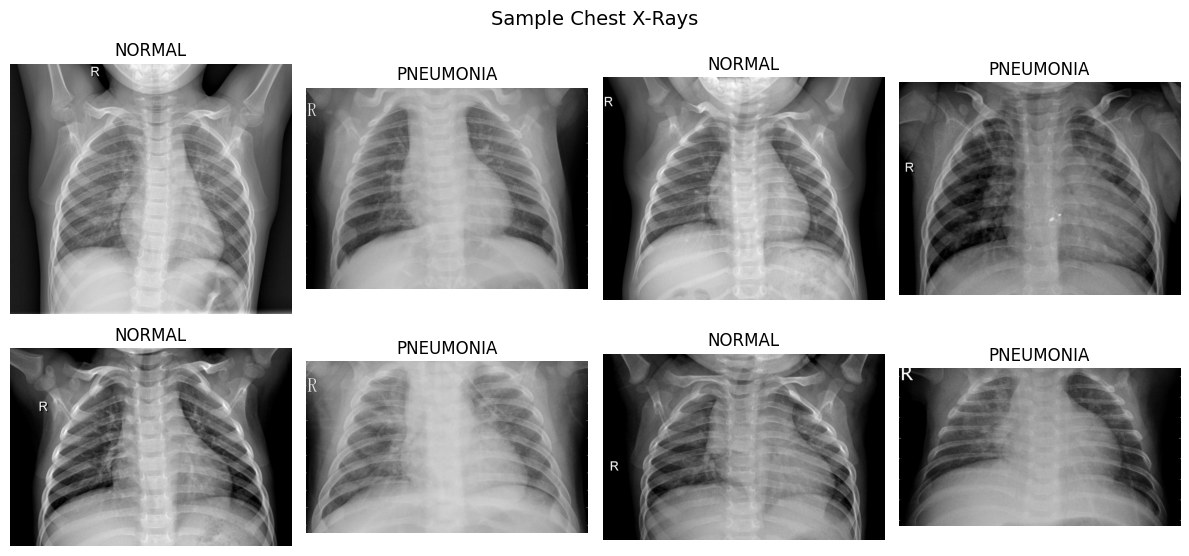

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):
    # alternate between normal and pneumonia
    label = 'NORMAL' if i % 2 == 0 else 'PNEUMONIA'
    folder = os.path.join(train_dir, label)
    img_file = os.listdir(folder)[i]
    img = plt.imread(os.path.join(folder, img_file))
    ax.imshow(img, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.suptitle('Sample Chest X-Rays', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.applications import VGG16

# Load pretrained model
base_model = VGG16(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze pretrained layers

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [11]:

from tensorflow.keras.callbacks import EarlyStopping

# Define early stop
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
print("✅ Early stop defined!")

# Train model
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)
print("✅ Training done!")

✅ Early stop defined!
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 686s 4s/step - accuracy: 0.8808 - loss: 0.2641 - val_accuracy: 0.8942 - val_loss: 0.2832
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 703s 4s/step - accuracy: 0.9365 - loss: 0.1567 - val_accuracy: 0.9054 - val_loss: 0.2609
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 714s 4s/step - accuracy: 0.9387 - loss: 0.1465 - val_accuracy: 0.9071 - val_loss: 0.2454
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 875s 5s/step - accuracy: 0.9461 - loss: 0.1346 - val_accuracy: 0.8990 - val_loss: 0.2825
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 791s 5s/step - accuracy: 0.9482 - loss: 0.1247 - val_accuracy: 0.8798 - val_loss: 0.3241
✅ Training done!


In [12]:

loss, accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss:     {loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.9071 - loss: 0.2454
Test Accuracy: 90.71%
Test Loss:     0.2454


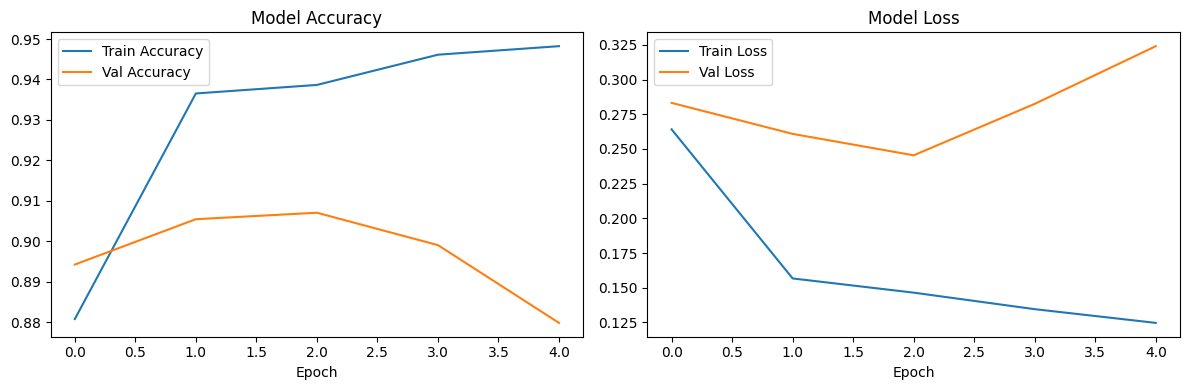

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
model.save('chest_xray_model.h5')
print("✅ Model saved!")

✅ Model saved!


In [20]:
from tensorflow.keras.preprocessing import image
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

# Load saved model
model = load_model('chest_xray_model.h5')
print("✅ Model loaded!")
def predict_xray(img_path):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)[0][0]

    # Show image
    plt.imshow(image.load_img(img_path))
    plt.axis('off')

    if prediction > 0.4:
        confidence = prediction * 100
        plt.title(f"🔴 PNEUMONIA ({confidence:.2f}%)", color='red')
    else:
        confidence = (1 - prediction) * 100
        plt.title(f"🟢 NORMAL ({confidence:.2f}%)", color='green')

    plt.show()

✅ Model loaded!


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step


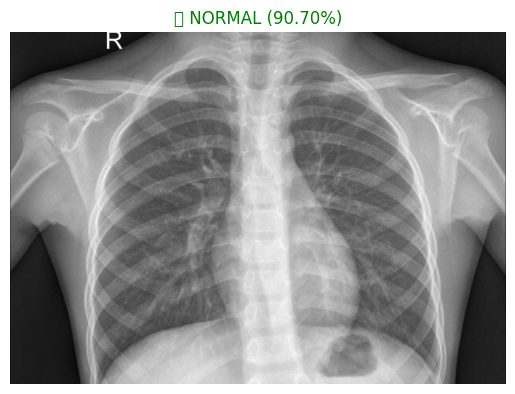

In [21]:
# Pick a random normal image
normal_folder = 'chest_xray/test/NORMAL'
sample_normal = os.path.join(normal_folder, os.listdir(normal_folder)[0])

predict_xray(sample_normal)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


C:\Users\Ikram Ul Haq\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


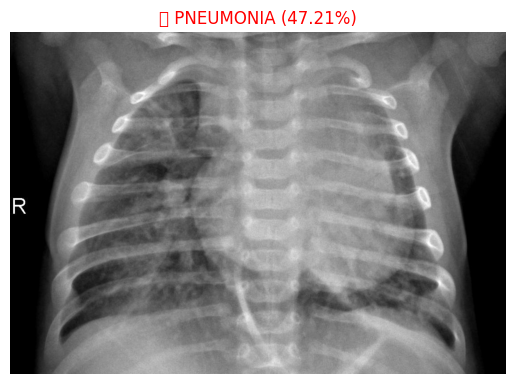

In [22]:
# Pick a random pneumonia image
pneumonia_folder = 'chest_xray/test/PNEUMONIA'
sample_pneumonia = os.path.join(pneumonia_folder, os.listdir(pneumonia_folder)[0])

predict_xray(sample_pneumonia)

normal done


C:\Users\Ikram Ul Haq\AppData\Local\Temp\ipykernel_968\1540292100.py:36: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Ikram Ul Haq\AppData\Local\Temp\ipykernel_968\1540292100.py:36: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


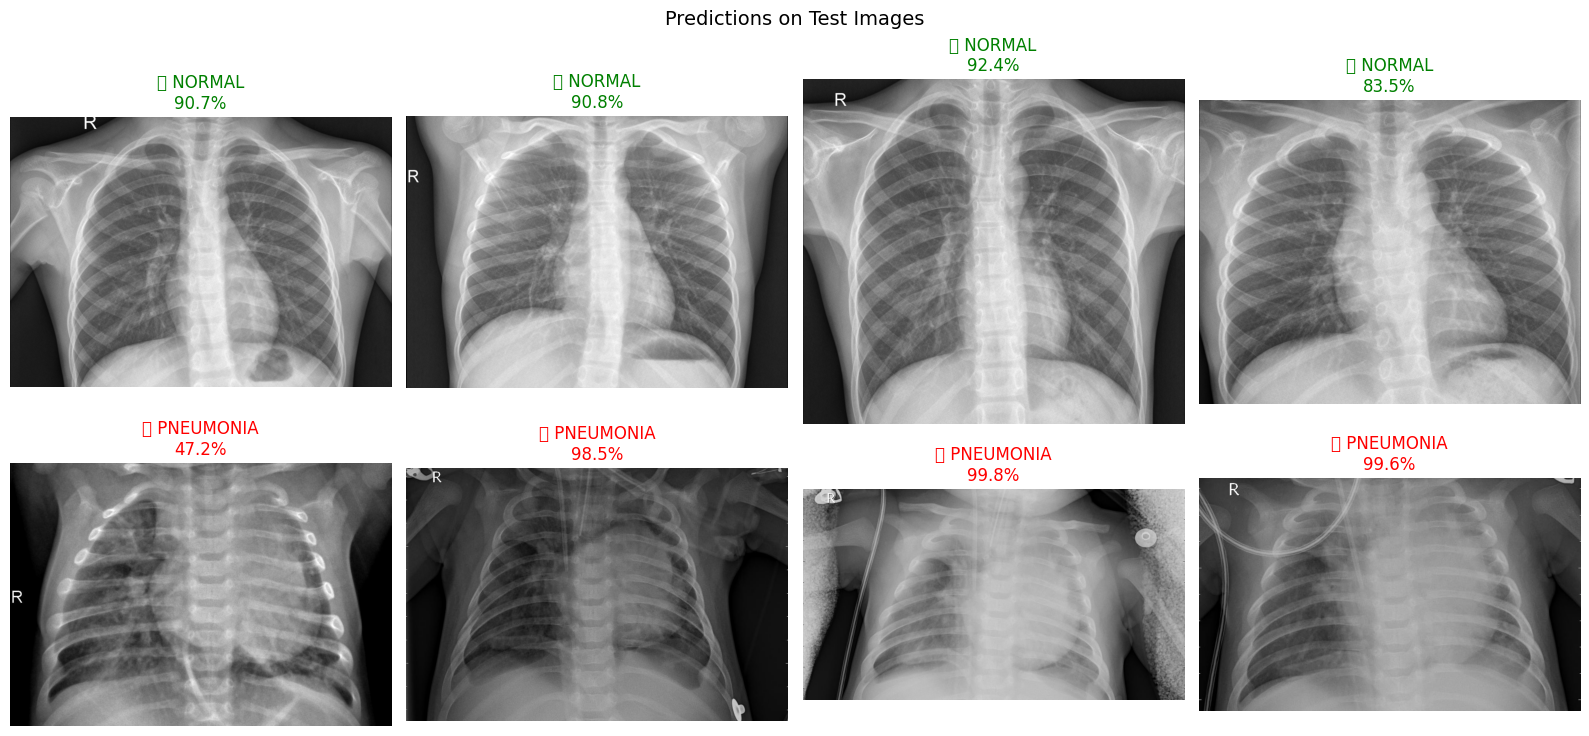

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

normal_files = os.listdir('chest_xray/test/NORMAL')[:4]
pneumonia_files = os.listdir('chest_xray/test/PNEUMONIA')[:4]

for i, (ax, fname) in enumerate(zip(axes[0], normal_files)):
    img_path = f'chest_xray/test/NORMAL/{fname}'
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array, verbose=0)[0][0]
    
    ax.imshow(image.load_img(img_path))
    ax.axis('off')
    if pred > 0.4:
        ax.set_title(f"🔴 PNEUMONIA\n{pred*100:.1f}%", color='red')
    else:
        ax.set_title(f"🟢 NORMAL\n{(1-pred)*100:.1f}%", color='green')

print("normal done")
for i, (ax, fname) in enumerate(zip(axes[1], pneumonia_files)):
    img_path = f'chest_xray/test/PNEUMONIA/{fname}'
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array, verbose=0)[0][0]
    
    ax.imshow(image.load_img(img_path))
    ax.axis('off')
    if pred > 0.4:
        ax.set_title(f"🔴 PNEUMONIA\n{pred*100:.1f}%", color='red')
    else:
        ax.set_title(f"🟢 NORMAL\n{(1-pred)*100:.1f}%", color='green')

plt.suptitle('Predictions on Test Images', fontsize=14)
plt.tight_layout()
plt.show()